/tmp/ipykernel_1286618/3681887950.py:19: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  ngc_data = imageio.imread(ngc_filename, mode='F', pilmode=None)
/tmp/ipykernel_1286618/3681887950.py:34: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  ngc_conv = scipy.ndimage.filters.gaussian_filter(ngc_square, sigma, mode='nearest', truncate=6)


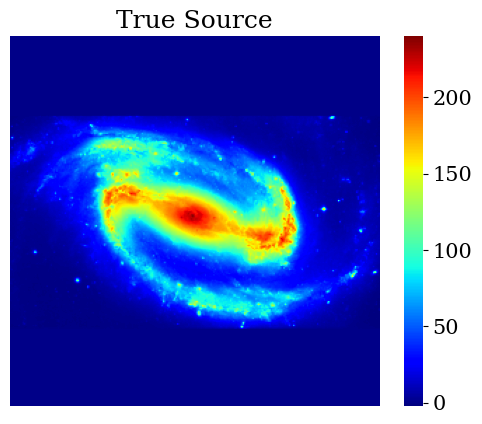

In [1]:
import imageio
import os
import numpy as np
import scipy
import lenstronomy.Util.util as util
import lenstronomy.Util.image_util as image_util
import matplotlib.pyplot as plt
from lenstronomy.LensModel.lens_model import LensModel
import matplotlib

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['axes.linewidth'] = 0.

path = os.getcwd()
dirpath, _ = os.path.split(path)
module_path, _ = os.path.split(dirpath)
ngc_filename = 'ngc1300.jpg'
ngc_data = imageio.imread(ngc_filename, mode='F', pilmode=None)

median = np.median(ngc_data[:200, :200])
ngc_data -= median

nx, ny = np.shape(ngc_data)
n_min = min(nx, ny)
n_max = max(nx, ny)
ngc_square = np.zeros((n_max, n_max))
x_start = int((n_max - nx)/2.)
y_start = int((n_max - ny)/2.)
ngc_square[x_start:x_start+nx, y_start:y_start+ny] = ngc_data

# we slightly convolve the image with a Gaussian convolution kernel of a few pixels (optional)
sigma = 5
ngc_conv = scipy.ndimage.filters.gaussian_filter(ngc_square, sigma, mode='nearest', truncate=6)

factor = 25  
numPix_large = int(len(ngc_conv)/factor)
n_new = int((numPix_large-1)*factor)
ngc_cut = ngc_conv[0:n_new,0:n_new]
x, y = util.make_grid(numPix=numPix_large-1, deltapix=1)  # make a coordinate grid
ngc_data_resized = image_util.re_size(ngc_cut, factor)  # re-size image to lower resolution

image_1d = util.image2array(ngc_data_resized)  # map 2d image in 1d data array

def makemask(array,a,b,angle):
    #makes an elliptical mask of a size and angle
    shp = np.shape(array)
    
    likemask = np.ones(shp)
    for i in range(shp[0]):
        for j in range(shp[1]):
            xprim = np.cos(angle)*(i-shp[0]/2.) + np.sin(angle)*(j-shp[1]/2.)
            yprim = np.cos(angle)*(j-shp[1]/2.) - np.sin(angle)*(i-shp[0]/2.)
            sqrsum = (xprim/a)**2 + (yprim/b)**2. 
            if sqrsum > 1:
                likemask[i,j] *= 0.001
    return likemask

from matplotlib import cm

plt.imshow(ngc_data_resized, cmap='jet')#, vmin=vmin, vmax=vmax)
plt.xticks([])
plt.yticks([])
plt.title('True Source')
plt.colorbar()
plt.show()

# JWST Quality Data for Comparison

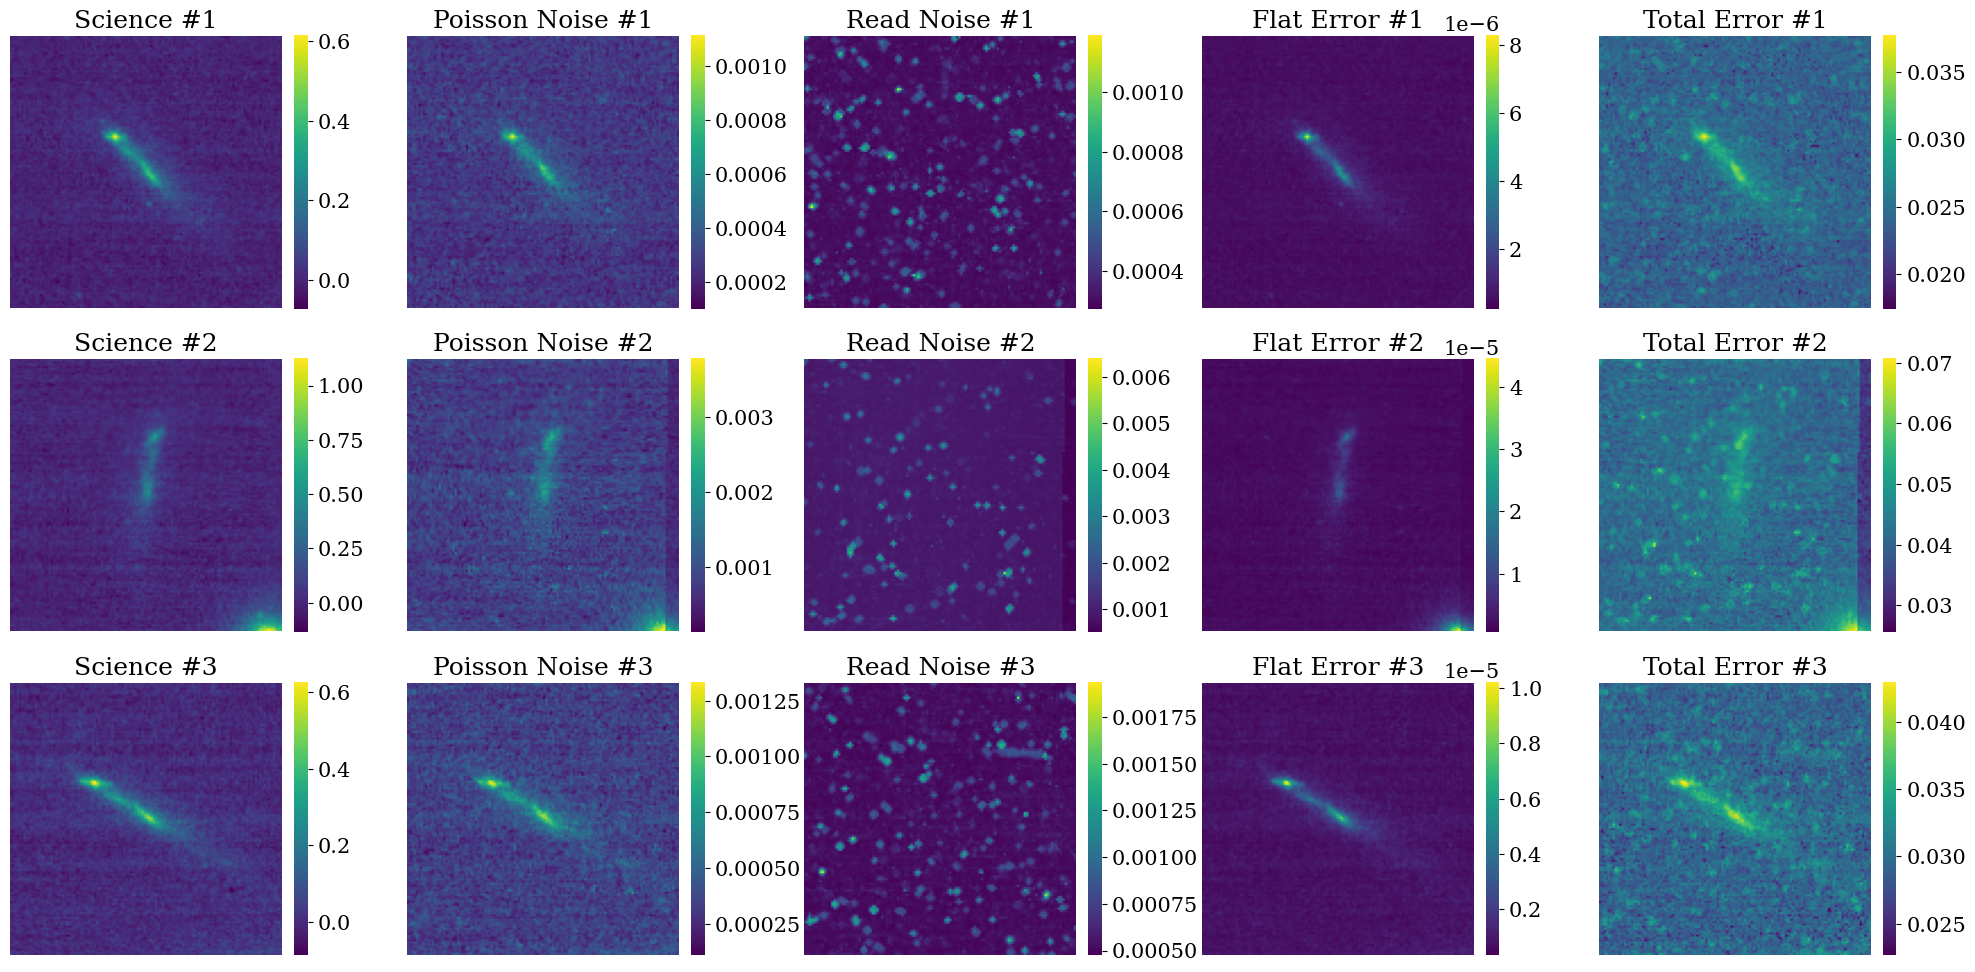

In [50]:
import numpy as np
import matplotlib.pyplot as plt

filt = 115

file_path = f"/n/netscratch/dvorkin_lab/Lab/nephremidze/mock_perturber/mock_noise_files/"

array200sci  = np.load(file_path+f'f{filt}w_image1_.npy')
array200pois = np.load(file_path+f'f{filt}w_poiss1.npy')
array200bkg  = np.load(file_path+f'f{filt}w_bkg1.npy')
array200flat = np.load(file_path+f'f{filt}w_flat1.npy')
array200err  = np.load(file_path+f'f{filt}w_error1_.npy')

array200sci2  = np.load(file_path+f'f{filt}w_image2_.npy')
array200pois2 = np.load(file_path+f'f{filt}w_poiss2.npy')
array200bkg2  = np.load(file_path+f'f{filt}w_bkg2.npy')
array200flat2 = np.load(file_path+f'f{filt}w_flat2.npy')
array200err2  = np.load(file_path+f'f{filt}w_error2_.npy')

array200sci3  = np.load(file_path+f'f{filt}w_image3_.npy')
array200pois3 = np.load(file_path+f'f{filt}w_poiss3.npy')
array200bkg3  = np.load(file_path+f'f{filt}w_bkg3.npy')
array200flat3 = np.load(file_path+f'f{filt}w_flat3.npy')
array200err3  = np.load(file_path+f'f{filt}w_error3_.npy')

# Order: (1) Science, (2) Poisson Noise, (3) Read Noise, (4) Flat Error, (5) Total Error.
data_sets = [
    (array200sci,   "Science #1"), 
    (array200pois,  "Poisson Noise #1"), 
    (array200bkg,   "Read Noise #1"), 
    (array200flat,  "Flat Error #1"), 
    (array200err,   "Total Error #1"),

    (array200sci2,  "Science #2"),
    (array200pois2, "Poisson Noise #2"),
    (array200bkg2,  "Read Noise #2"),
    (array200flat2, "Flat Error #2"),
    (array200err2,  "Total Error #2"),

    (array200sci3,  "Science #3"),
    (array200pois3, "Poisson Noise #3"),
    (array200bkg3,  "Read Noise #3"),
    (array200flat3, "Flat Error #3"),
    (array200err3,  "Total Error #3")
]

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 10))

for ax, (img, title) in zip(axes.flat, data_sets):

    im = ax.imshow(img, origin='lower', cmap='viridis')
    ax.set_title(title)
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.axis('off')

plt.tight_layout()
plt.show()


In [3]:
# Find Signal to POISSON Noise Ratio

idx = np.argmax(array200sci)
row, col = np.unravel_index(idx, array200sci.shape)

SNR_poiss_jwst = np.max(array200sci) / array200pois[row, col]

print("SNR at center:", SNR_poiss_jwst)

SNR at center: 551.2989563995351


Background RMS: 0.016971515354142264


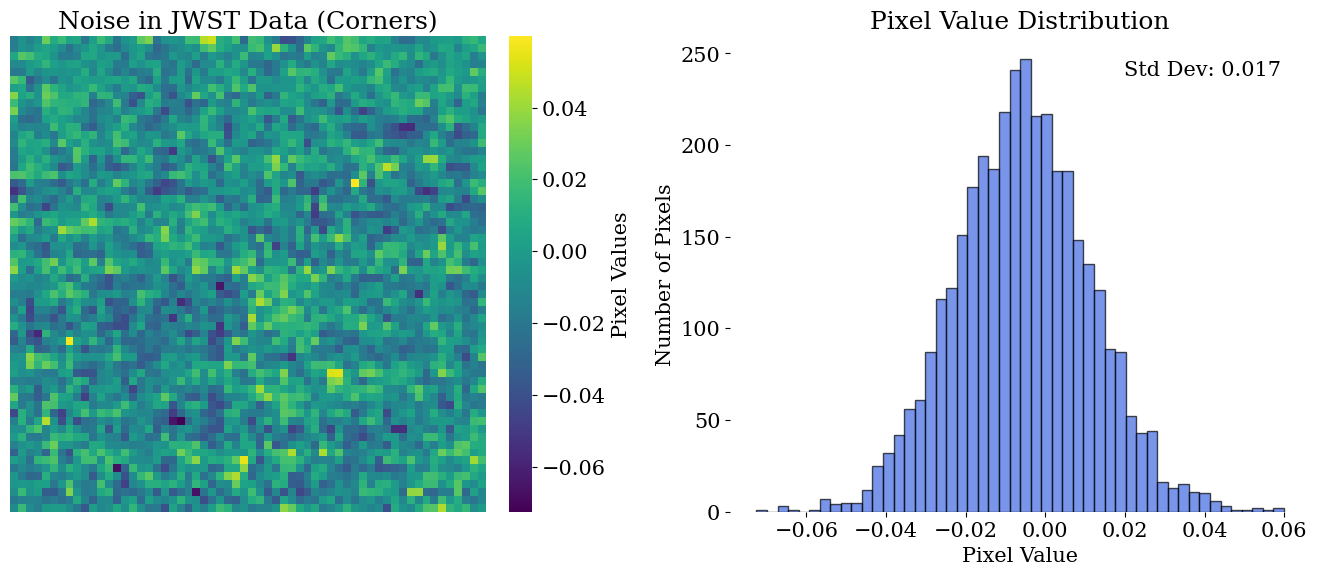

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper function to grab corners and block them into one array ---
def get_corners(arr, corner_size=30):
    """
    Given a 2D array 'arr', return a single corner-mosaic array of shape, combining:
     - top-left, top-right
     - bottom-left, bottom-right
    """
    corner1 = arr[0:corner_size, 0:corner_size]           # top-left
    corner2 = arr[-corner_size:, -corner_size:]           # bottom-right
    corner3 = arr[0:corner_size, -corner_size:]           # top-right
    corner4 = arr[-corner_size:, 0:corner_size]           # bottom-left

    corners = np.block([
        [corner1, corner3],
        [corner4, corner2]
    ])
    return corners

# --- Extract corner mosaics from your arrays ---
corners1 = get_corners(array200sci)
corners3 = get_corners(array200sci3)

# --- Combine these corner mosaics side-by-side ---
all_corners = np.block([
    [corners1]
])

# --- Calculate background RMS for these corners ---
bck_rms = np.std(all_corners)
print("Background RMS:", bck_rms)

# --- Plot the corner mosaic and the histogram side by side ---
fig, (ax_img, ax_hist) = plt.subplots(1, 2, figsize=(14, 6))

# Left subplot: the corner mosaic image
im = ax_img.imshow(all_corners, origin='lower', cmap='viridis')
ax_img.set_title("Noise in JWST Data (Corners)")
ax_img.axis('off')  # Turn off axis ticks
cb = plt.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04)
cb.set_label("Pixel Values")

# Right subplot: the histogram of pixel values
vals = all_corners.ravel()  # Flatten the 2D array into 1D
ax_hist.hist(vals, bins=50, color='royalblue', alpha=0.7, edgecolor='black')
ax_hist.set_title("Pixel Value Distribution")
ax_hist.set_xlabel("Pixel Value")
ax_hist.set_ylabel("Number of Pixels")

ax_hist.text(
    0.95, 0.95,
    f"Std Dev: {bck_rms:.3f}",
    ha='right', va='top',
    transform=ax_hist.transAxes,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8)
)

plt.tight_layout()
plt.show()


# JWST Quality Mocks

In [52]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Util import util, image_util
import astropy.io.fits as pyfits
import scipy.signal as signal

num_imgs = 3

rad_stretches = [1., 2., 1.]
tan_stretches = [5., 3., 3.]
curvatures = [0.1, 0.1, 0.1]
orientations = [0.2, 0.1, -0.2]

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['axes.linewidth'] = 0.

def make_mocks(
    subhalo_params,
    mocks_no_pert=None,
    mocks_no_pert_err=None
):
    """
    Generate 3 mock images (with or without subhalo),
    and optionally compute residuals vs. smooth mocks (without subhalo).
    
    Parameters
    ----------
    subhalo_params : list or tuple
        Subhalo parameters, e.g. [M200, concentration, x_p, y_p].
    mocks_no_pert : list of 2D arrays, optional
        The 3 unperturbed mock images (without subhalo). 
        If provided, residuals are computed and plotted in the 5th column.
    mocks_no_pert_err : list of 2D arrays, optional
        The 3 unperturbed mock error maps. 
        Used to compute normalized residuals if provided.
    """
    mocks = []
    mocks_err = []
    mags = []

    # -------------------------------------------------------
    # 1) CREATE A SINGLE FIGURE AND 3×5 AXES 
    # -------------------------------------------------------
    fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 10))

    for i in range(num_imgs):

        # ----------------------------------------------------------------
        # Only include subhalo in second image (i = 1).
        # ----------------------------------------------------------------
        cab_type = 'CURVED_ARC_SIS_MST'
        kwargs_lens_main = {
            'radial_stretch': rad_stretches[i],
            'tangential_stretch': tan_stretches[i],
            'curvature': np.abs(curvatures[i]),
            'direction': orientations[i]*np.pi - (np.sign(curvatures[i])+1.)*np.pi/2.,
            'center_x': 0, 
            'center_y': 0
        }
        lens_model_list = [cab_type]
        kwargs_lens_list = [kwargs_lens_main]

        subhalo_type = 'NFW'
        num_subhalo = 1

        z_lens = 0.348
        z_source = 1.398

        from astropy.cosmology import default_cosmology
        cosmo = default_cosmology.get()
        from lenstronomy.Cosmo.lens_cosmo import LensCosmo
        lensCosmo = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)

        M200 = subhalo_params[0]
        concentration = subhalo_params[1]
        Rs_angle_clump, theta_Rs_clump = lensCosmo.nfw_physical2angle(M=M200, c=concentration)
        x_p = subhalo_params[2]
        y_p = subhalo_params[3]

        if i == 1:
            lens_model_list.append(subhalo_type)
            kwargs_lens_list.append({
                'Rs': Rs_angle_clump, 
                'alpha_Rs': theta_Rs_clump,
                'center_x': x_p, 
                'center_y': y_p
            })

        lensModel = LensModel(lens_model_list)
        x_grid, y_grid = util.make_grid(numPix=120, deltapix=0.05)

        # -------------------------------------------------
        # 1) Magnification Field
        # -------------------------------------------------
        mag = lensModel.magnification(x_grid, y_grid, kwargs_lens_list)
        mag = util.array2image(mag)
        mags.append(mag)

        # -------------------------------------------------
        # 2) Ray Tracing in high-res, then map onto source
        # -------------------------------------------------
        numPix = 120
        deltaPix = 0.031230659851709842
        high_res_factor = 3
        theta_x_high_res, theta_y_high_res = util.make_grid(
            numPix=numPix * high_res_factor, 
            deltapix=deltaPix / high_res_factor
        )
        beta_x_high_res, beta_y_high_res = lensModel.ray_shooting(
        theta_x_high_res, theta_y_high_res, kwargs=kwargs_lens_list
        )
        # -------------------------------------------------
        # 3) Interpolated Source Light
        # -------------------------------------------------
        kwargs_interp = {
            'image': ngc_data_resized,  # your loaded/processed source image
            'center_x': 0, 
            'center_y': 0, 
            'scale': 0.005, 
            'phi_G': 0.2
        }
        from lenstronomy.LightModel.Profiles.interpolation import Interpol
        interp_light = Interpol()
        source_lensed_interp = interp_light.function(
            beta_x_high_res, beta_y_high_res, **kwargs_interp
        )
        source_lensed = util.array2image(source_lensed_interp)

        # Match JWST flux (align brightest pixels)
        jwst_flux_ratio = np.max(source_lensed) / np.max(array200sci)
        source_lensed /= jwst_flux_ratio

        # -------------------------------------------------
        # 4) PSF Convolution
        # -------------------------------------------------
        path = (
            f'/n/holyscratch01/dvorkin_lab/nephremidze/abell-s1063/small_masks/'
            f'delaunay/CAB_with_Delaunay/analysis_data/small_masks/f{filt}w/'
        )
        kernel = np.load(path + f'jwst_psf_{filt}_sim.npy')

        import lenstronomy.Util.kernel_util as kernel_util
        kernel_subsampled = kernel_util.subgrid_kernel(kernel, high_res_factor, odd=True, num_iter=5)
        kernel_subsampled = kernel_util.cut_psf(
            psf_data=kernel_subsampled,
            psf_size=len(kernel_subsampled) - 30 * high_res_factor
        )

        import scipy.signal as signal
        image_convolved = signal.fftconvolve(source_lensed, kernel_subsampled, mode='same')
        image_conv_resized = image_util.re_size(image_convolved, high_res_factor)

        # -------------------------------------------------
        # 5) Noise Addition
        # -------------------------------------------------
        exposure_time = 1
        poisson_realization = image_util.add_poisson(image_conv_resized, exp_time=exposure_time)
        bkg_realization = image_util.add_background(image_conv_resized, sigma_bkd=bck_rms)

        idx = np.argmax(image_conv_resized)
        row_peak, col_peak = np.unravel_index(idx, image_conv_resized.shape)
        SNR_poisson_current = np.max(image_conv_resized) / np.sqrt(
            np.max(np.abs(image_conv_resized))
        )
        # Scale Poisson to match JWST
        scale_factor = (SNR_poiss_jwst / SNR_poisson_current)
        poisson_realization /= scale_factor

        image_noisy = image_conv_resized + poisson_realization + bkg_realization
        mocks.append(image_noisy)

        poisson_noise = np.sqrt(np.abs(image_conv_resized))
        mock_error = poisson_noise / scale_factor + bck_rms
        mocks_err.append(mock_error)

        # ------------------------------------------------------------
        # PLOT THE SUMMARY FIGURE
        # ------------------------------------------------------------
        # Column 0: Magnification Field
        ax0 = axes[i, 0]
        ax0.matshow(np.log10(mag), origin='lower', cmap='viridis')
        ax0.set_title('Magnification')
        ax0.set_xticks([])
        ax0.set_yticks([])

        # Column 1: Lensed Source (before convolution)
        ax1 = axes[i, 1]
        ax1.matshow(source_lensed, origin='lower', cmap='jet')
        ax1.set_title('Lensed Source')
        ax1.set_xticks([])
        ax1.set_yticks([])

        # Column 2: Convolved Image
        ax2 = axes[i, 2]
        ax2.matshow(image_conv_resized, origin='lower', cmap='jet')
        ax2.set_title('F115W PSF Convolved')
        ax2.set_xticks([])
        ax2.set_yticks([])

        # Column 3: Convolved + Noise
        ax3 = axes[i, 3]
        ax3.matshow(image_noisy, origin='lower', cmap='jet')
        ax3.set_title('Noise Added')
        ax3.set_xticks([])
        ax3.set_yticks([])

        # Column 4 (optional): Residual vs. "no-perturber" image
        if mocks_no_pert is not None and mocks_no_pert_err is not None:
            # Residuals normalized by error
            diff_img = (image_noisy - mocks_no_pert[i]) / mocks_no_pert_err[i]

            ax4 = axes[i, 4]
            im = ax4.matshow(diff_img, origin='lower', cmap='bwr', vmin=-5, vmax=5)
            ax4.set_title('Residual vs. No-Pert')
            ax4.set_xticks([])
            ax4.set_yticks([])

            cbar = plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=10)

        else:
            # If no "no_pert" data is given, we just plot an empty axis
            axes[i, 4].axis('off')

    plt.tight_layout()
    plt.suptitle(f"Mocks with $M_{{{200}}} = {{{str(M200)[0]}}} \\times 10^{{{int(np.log10(M200))}}} M_{{\odot}}$", fontsize=25, y=1.04)
    
    for i in range(3):
        for j in range(4):
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

    for i in range(3):
        axes[i, 0].set_ylabel(f"Img#{i+1}", rotation=90)

    plt.subplots_adjust(left=0.15)
    plt.show()
    
    return mocks, mocks_err


In [45]:
x_p, y_p = 0.3, 0.3

/tmp/ipykernel_1286618/3612999908.py:185: RuntimeWarning: invalid value encountered in log10
  ax0.matshow(np.log10(mag), origin='lower', cmap='viridis')


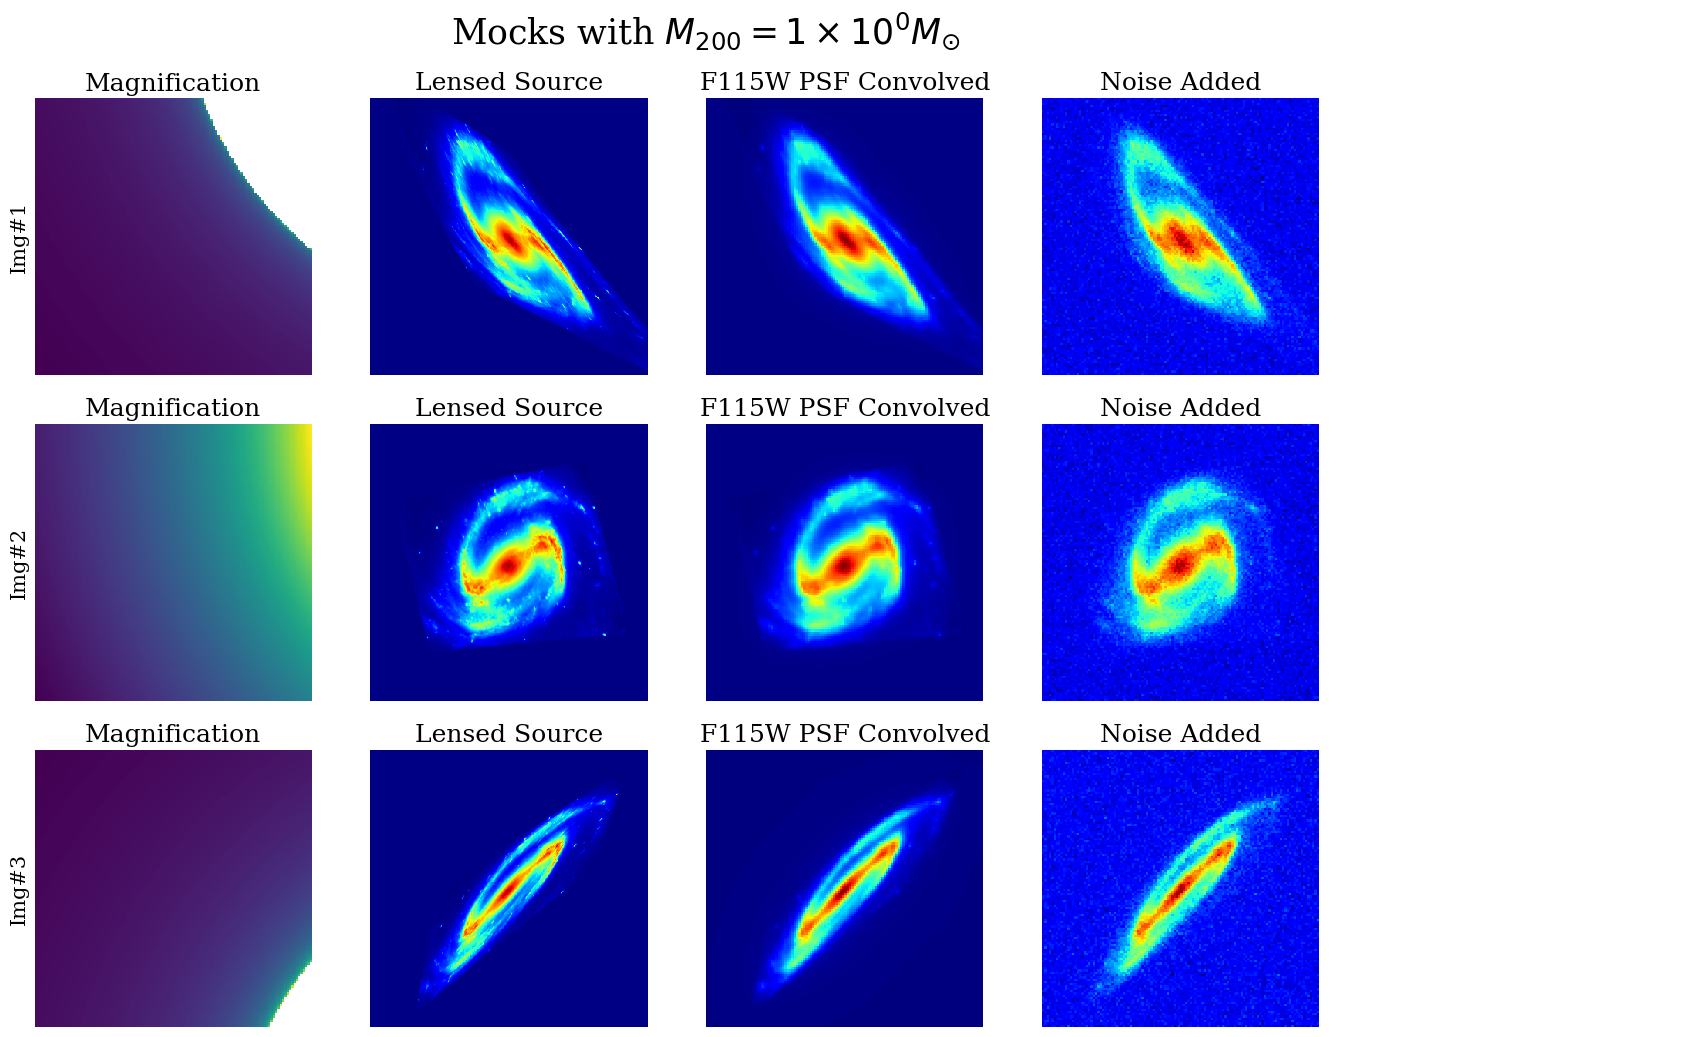

In [46]:
mocks0, mocks_err0 = make_mocks([1, 16., x_p, y_p])

/tmp/ipykernel_1286618/3612999908.py:185: RuntimeWarning: invalid value encountered in log10
  ax0.matshow(np.log10(mag), origin='lower', cmap='viridis')


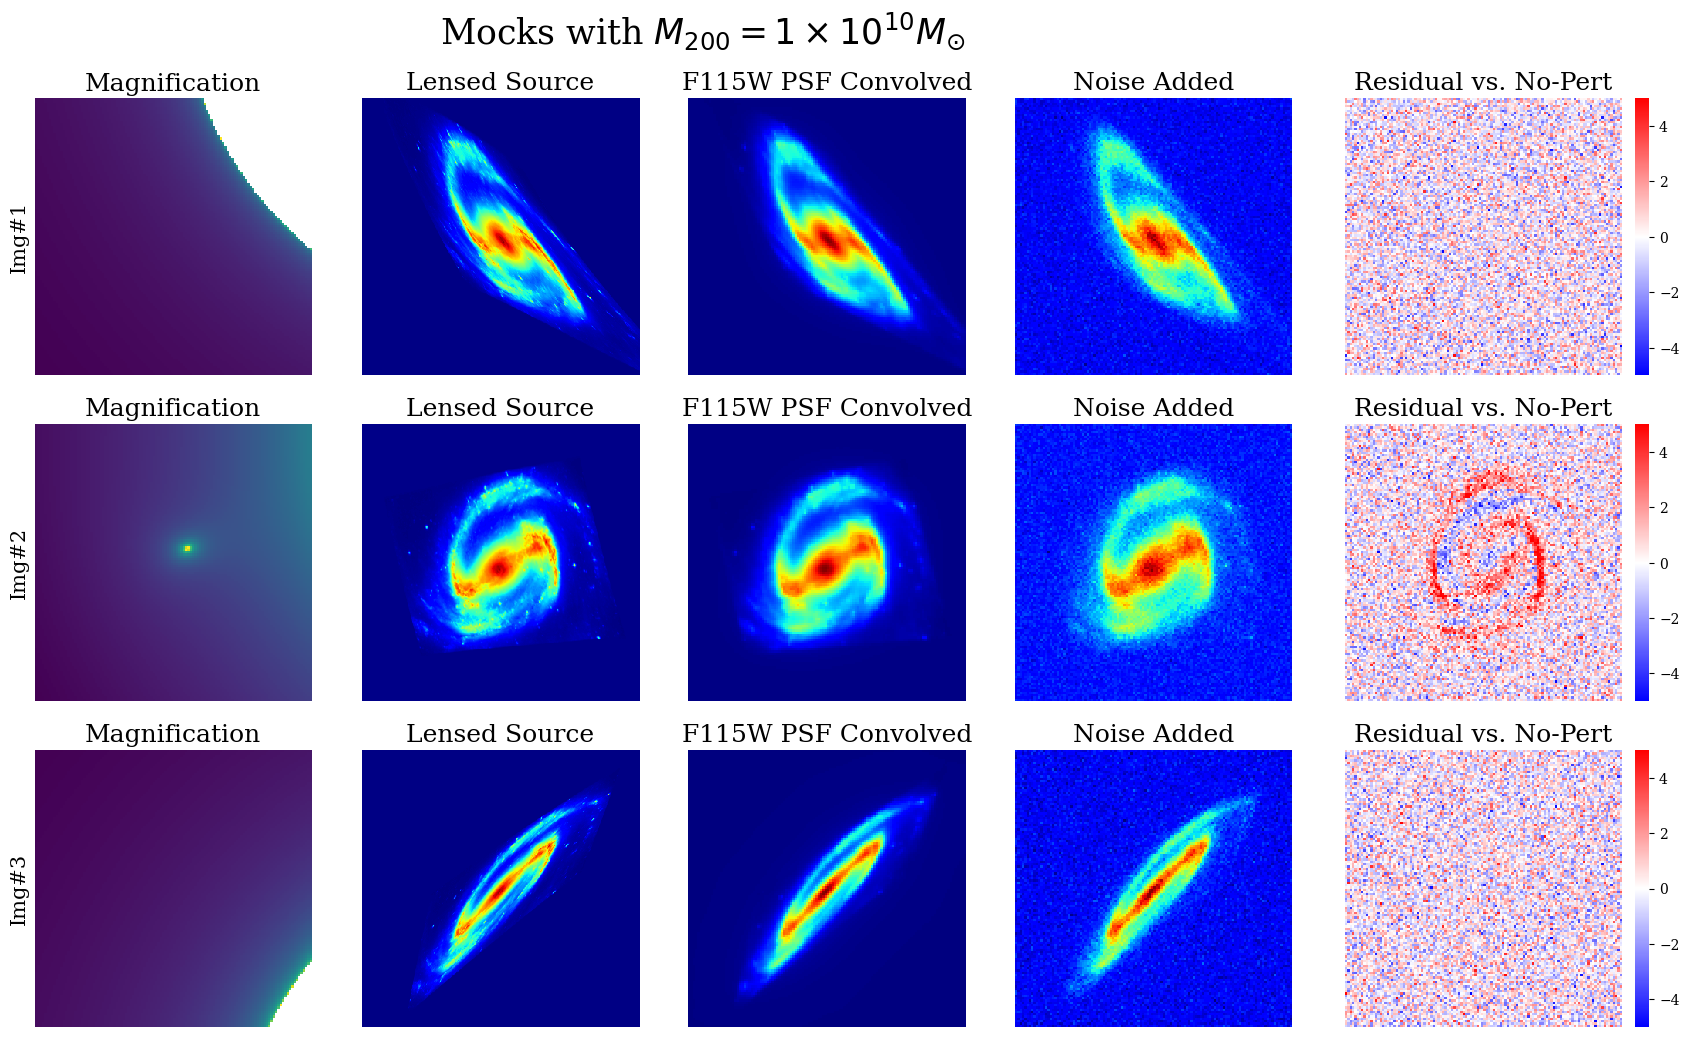

In [47]:
mocks1e10, mocks_err1e10 = make_mocks([1e10, 16., x_p, y_p],
                                      mocks_no_pert=mocks0,
                                      mocks_no_pert_err=mocks_err0)

/tmp/ipykernel_1286618/3612999908.py:185: RuntimeWarning: invalid value encountered in log10
  ax0.matshow(np.log10(mag), origin='lower', cmap='viridis')


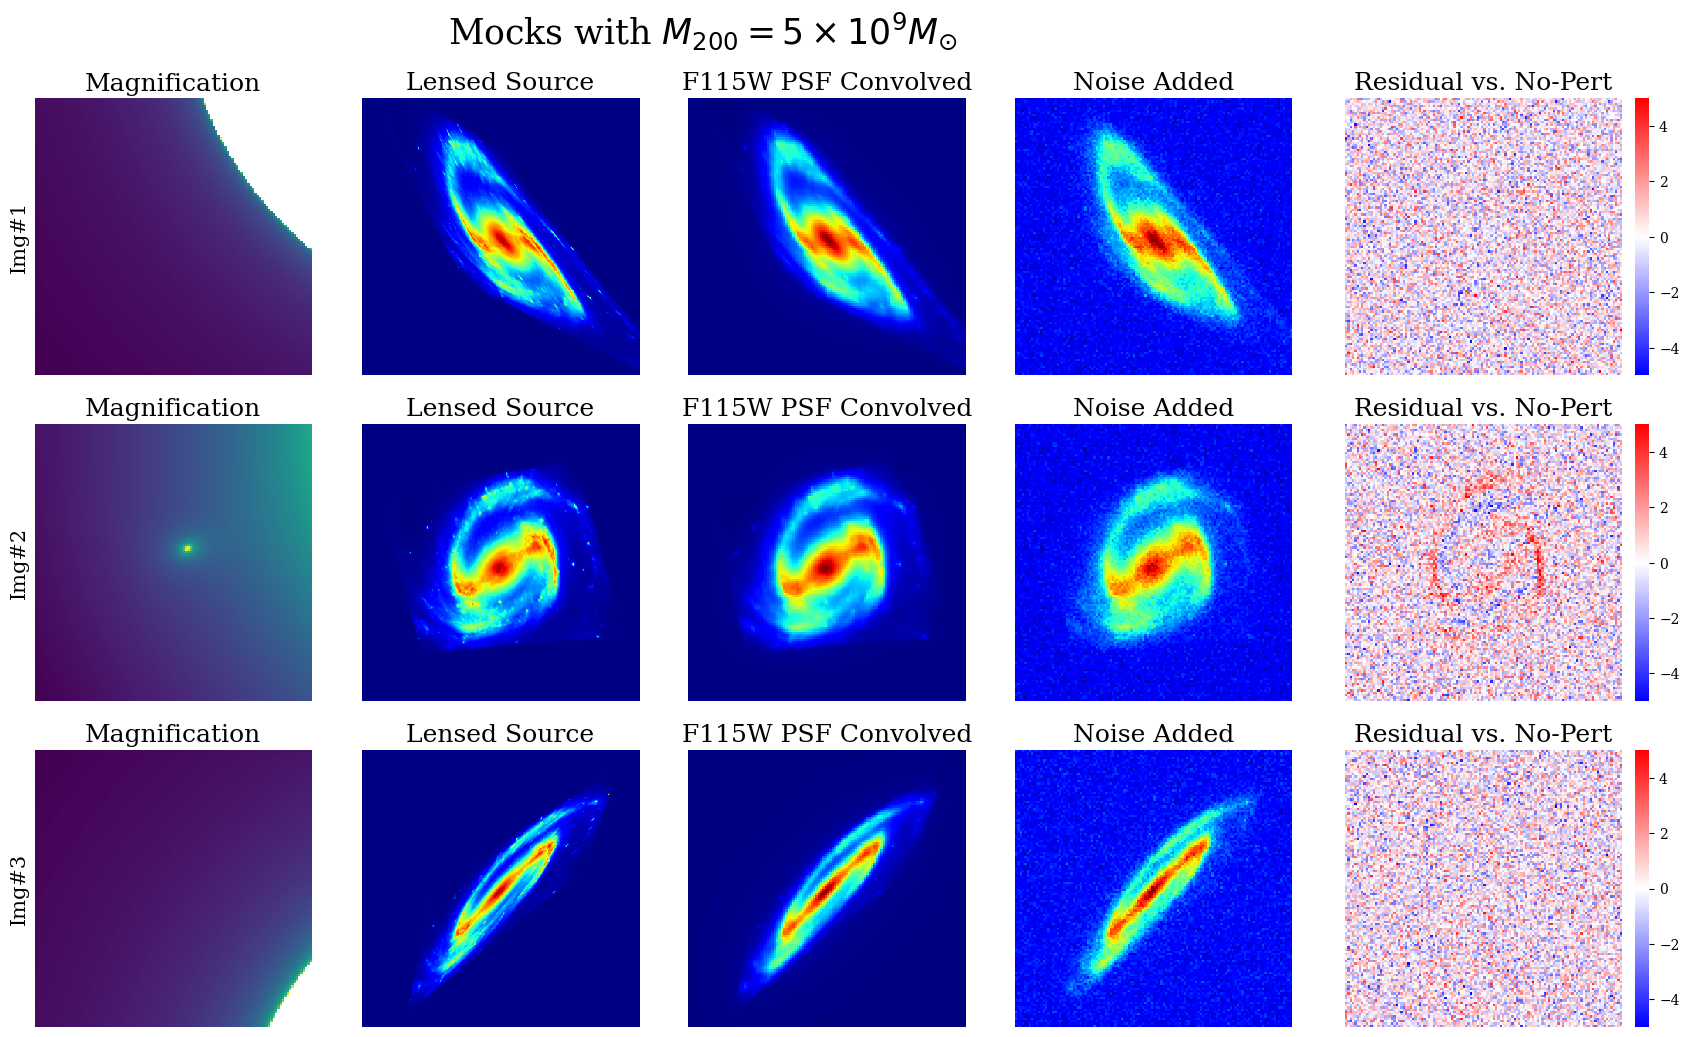

In [48]:
mocks5e9, mocks_err5e9 = make_mocks([5e9, 16., x_p, y_p],
                                      mocks_no_pert=mocks0,
                                      mocks_no_pert_err=mocks_err0)

/tmp/ipykernel_1286618/3612999908.py:185: RuntimeWarning: invalid value encountered in log10
  ax0.matshow(np.log10(mag), origin='lower', cmap='viridis')


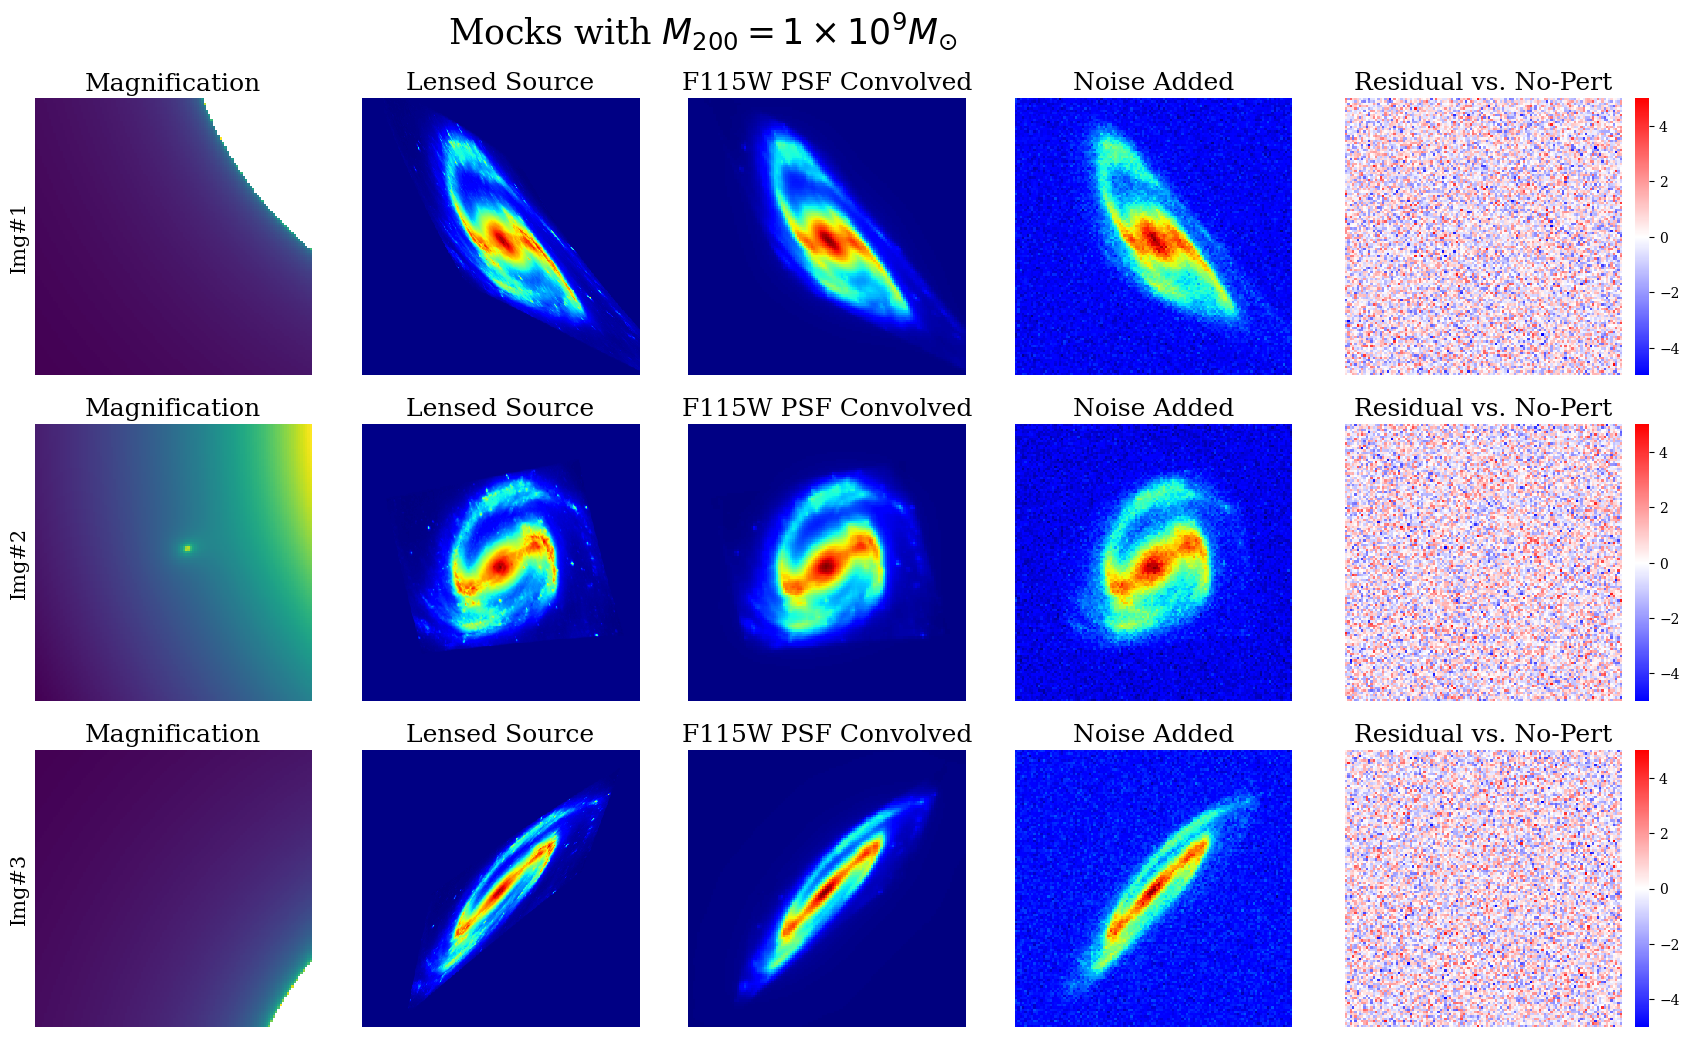

In [49]:
mocks1e9, mocks_err1e9 = make_mocks([1e9, 16., x_p, y_p],
                                      mocks_no_pert=mocks0,
                                      mocks_no_pert_err=mocks_err0)

# Save each set of mock files

In [15]:
import os
import numpy as np

M200s = ['1', '1e9', '5e9', '1e10']

for M200 in M200s:

    if M200 == '1e10':
        mocks = mocks1e10
        mocks_err = mocks_err1e10
    if M200 == '1e9':
        mocks = mocks1e9
        mocks_err = mocks_err1e9
    if M200 == '5e9':
        mocks = mocks5e9
        mocks_err = mocks_err5e9
    if M200 == '1':
        mocks = mocks0
        mocks_err = mocks_err0

    output_dir = f'mock_data/realistic_noise/{M200}'
    os.makedirs(output_dir, exist_ok=True)

    np.save(os.path.join(output_dir, f'mock1_f{filt}w.npy'), mocks[0])
    np.save(os.path.join(output_dir, f'mock2_f{filt}w.npy'), mocks[1])
    np.save(os.path.join(output_dir, f'mock3_f{filt}w.npy'), mocks[2])

    np.save(os.path.join(output_dir, f'mock1err_f{filt}w.npy'), mocks_err[0])
    np.save(os.path.join(output_dir, f'mock2err_f{filt}w.npy'), mocks_err[1])
    np.save(os.path.join(output_dir, f'mock3err_f{filt}w.npy'), mocks_err[2])
